This Step teaches us how to load validation and testing data for keras.

In [1]:
#Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/'  # Change to your dataset path
#DATASET_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/train_data/'
DATASET_DIR = './insects_dataset/'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")




2026-04-07 21:50:15.548026: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 21:50:15.573468: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading dataset with 80/20 train-validation split...
Found 2664 files belonging to 2 classes.
Using 2132 files for training.
Found 2664 files belonging to 2 classes.
Using 532 files for validation.
Classes found: ['test_data', 'train_data']


This Step optimises the dataset for performance.

In [2]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

This step randomly flips, rotates and zooms in the images. It then shows us some of them. 

2026-04-07 21:50:20.124696: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


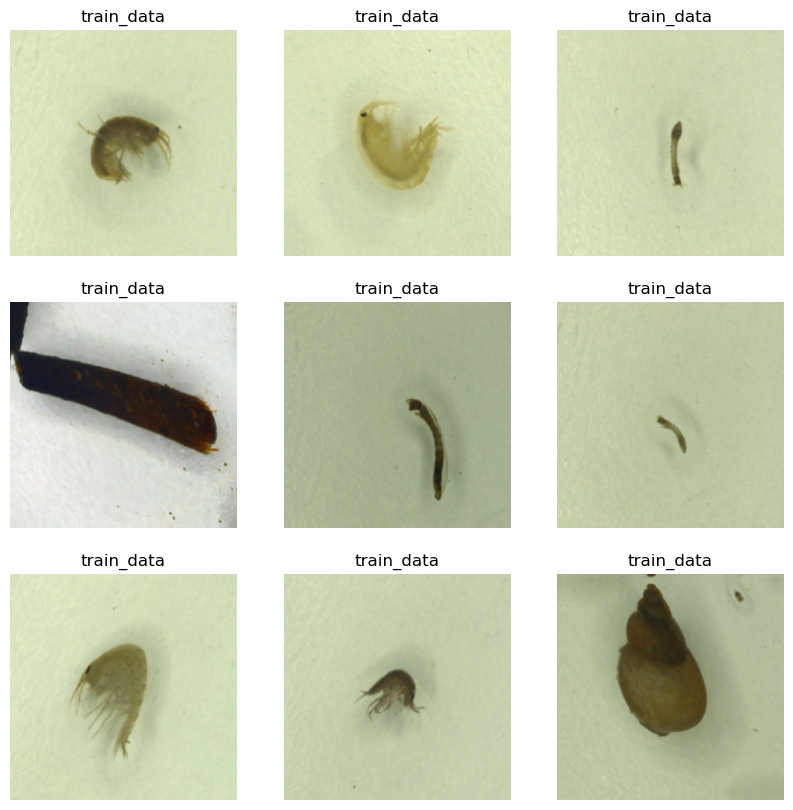

In [3]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

This Step compiles a model and has a certain amount of trainable and non-trainable parameters.

In [4]:
# === STEP 4: Build transfer learning model ===

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

This step trains the model.

In [5]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step - accuracy: 0.9897 - loss: 0.0590 - val_accuracy: 0.9906 - val_loss: 0.0559
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.9953 - loss: 0.0294 - val_accuracy: 0.9906 - val_loss: 0.0414
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 229ms/step - accuracy: 0.9953 - loss: 0.0273 - val_accuracy: 0.9906 - val_loss: 0.0381
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 235ms/step - accuracy: 0.9953 - loss: 0.0255 - val_accuracy: 0.9906 - val_loss: 0.0341
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - accuracy: 0.9953 - loss: 0.0208 - val_accuracy: 0.9906 - val_loss: 0.0323
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - accuracy: 0.9948 - loss: 0.0176 - val_accuracy: 0.9906 - val_loss: 0.0341
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 234ms/step - accuracy: 0.9953 - loss: 0.0177 - val_accuracy: 0.9906 - val_loss: 0.0294
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 231ms/step - accuracy: 0.9962 - loss: 0.0151 - val_accu

This step shows us the accuracy of the validation and training data and how much we lost from both of them. 

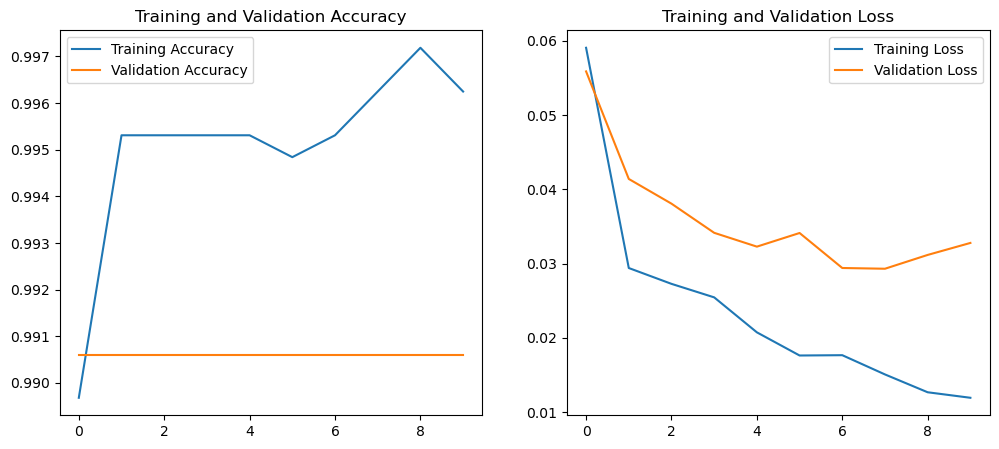

In [6]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

This step checks how accurate our validation dataset was.

In [7]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.9906 - loss: 0.0328
Validation accuracy: 99.06%


This step saves the model we've just trained.

In [8]:
# === STEP 9: Save the trained model ===
#%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

Model saved as 'macroinvertebrates_classifier.h5'


This step shows us the confusion matrix, how weighted the precision, recall and f1-score was, as well as the fact that the test_data slowly increased its true positive rate over time until the end where it jumped up to 100%.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step


2026-04-07 21:53:06.300380: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<Figure size 1200x1200 with 0 Axes>

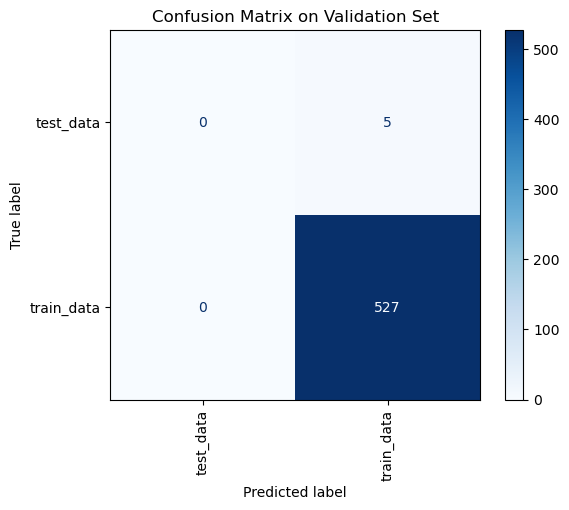

Weighted Precision: 0.9813
Weighted Recall:    0.9906
Weighted F1-score:  0.9859


/nix/store/6y24wb9v42dvr59hzldm0pk2nqy5ym7v-python3-3.13.12-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


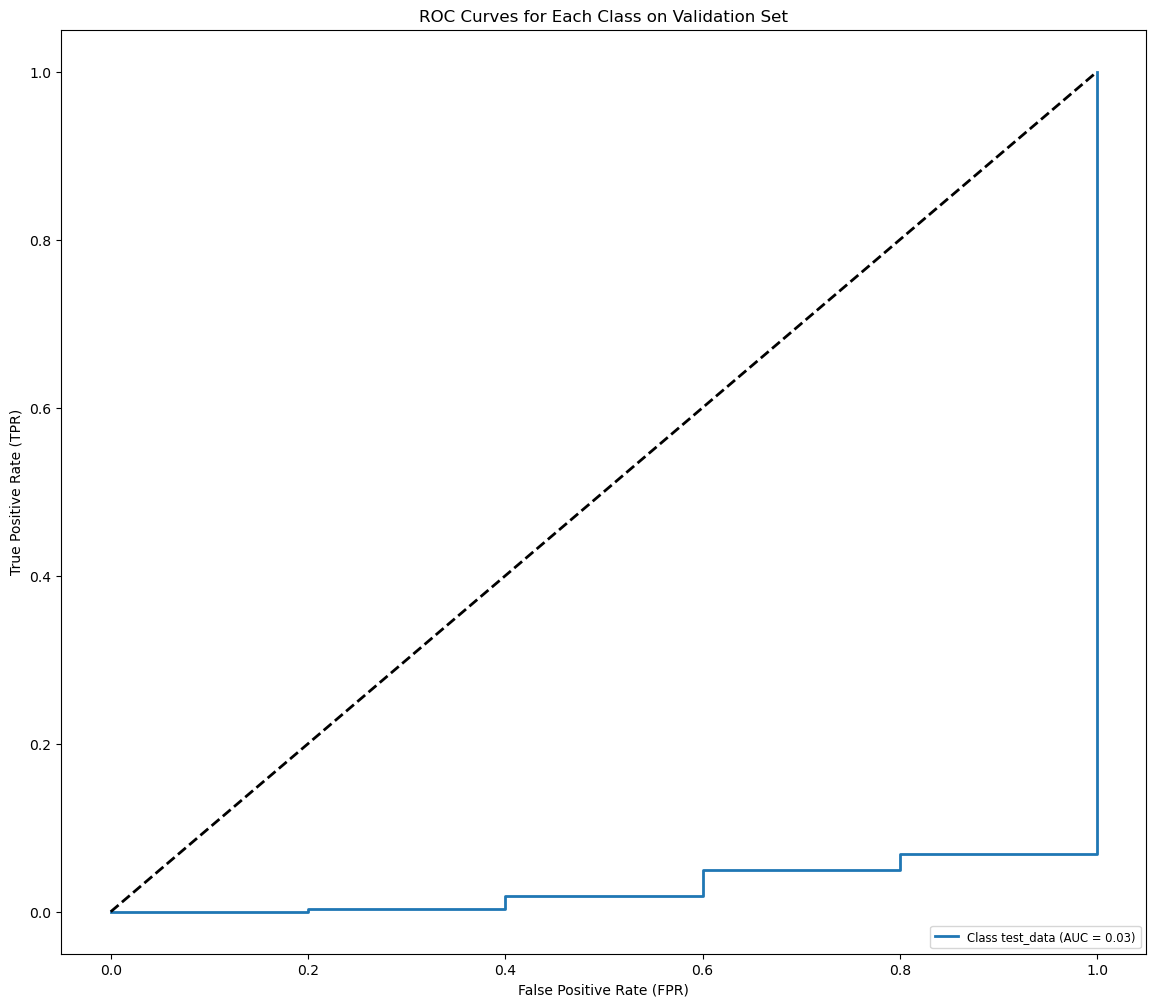

In [9]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



This step makes sure that the test_data folder has files, it then loads and processes them and then runs inferences on them.

Running inference on images from 'test_images' folder...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Original Image: CPH-Leuctra sp.-1910-t.png --> Predicted: train_data (98.79%)


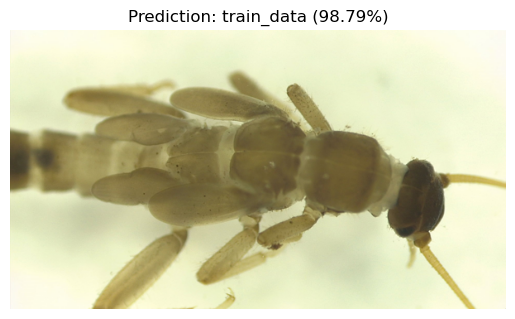

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Original Image: CPH-Leuctra sp.-1906-t.png --> Predicted: train_data (98.83%)


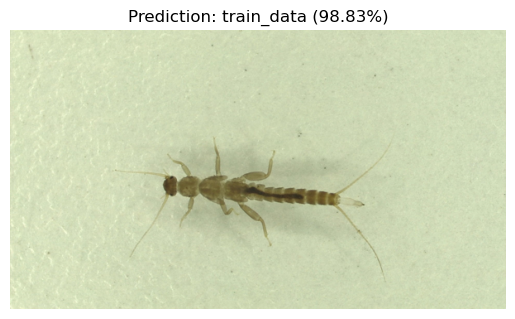

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Original Image: CPH-Leuctra sp.-1914-t.png --> Predicted: train_data (98.83%)


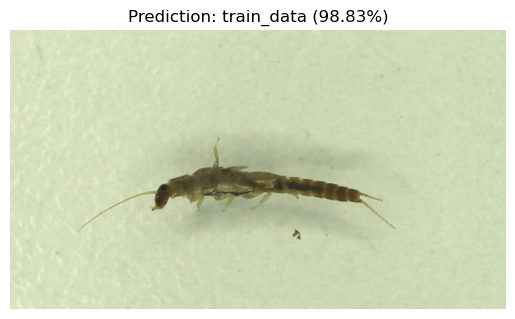

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Original Image: CPH-Limnius sp.-1923-t.png --> Predicted: train_data (98.78%)


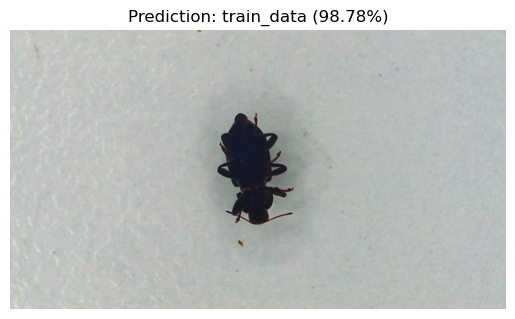

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Original Image: CPH-Leptophlebiidae sp.-1899-t.png --> Predicted: train_data (98.74%)


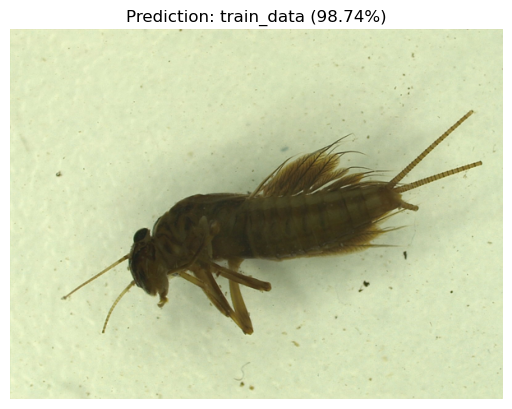

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Original Image: CPH-Leptophlebiidae sp.-1898-t.png --> Predicted: train_data (98.78%)


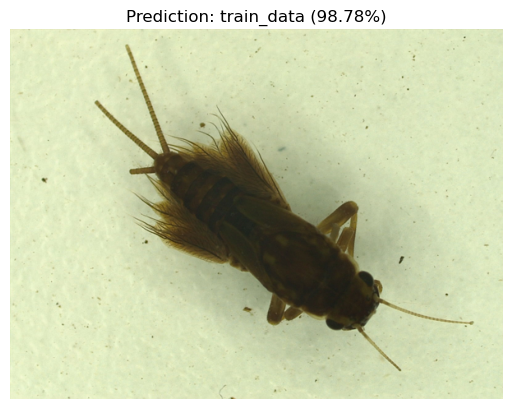

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Original Image: CPH-Leptophlebiidae sp.-1896-t.png --> Predicted: train_data (98.83%)


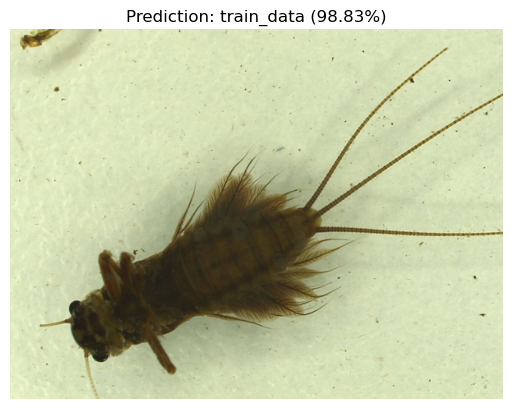

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Original Image: CPH-Limnius sp.-1927-t.png --> Predicted: train_data (98.65%)


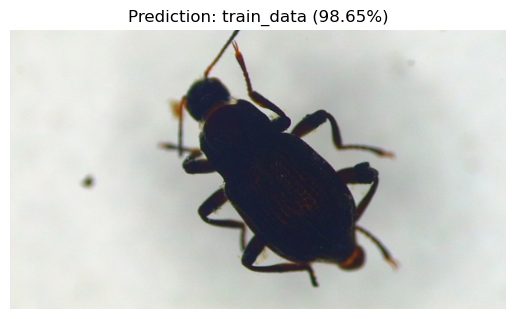

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Original Image: CPH-Leptophlebiidae sp.-1895-t.png --> Predicted: train_data (98.82%)


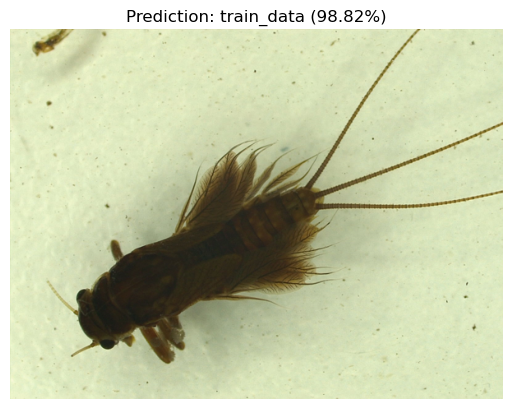

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Original Image: CPH-Leptophlebiidae sp.-1897-t.png --> Predicted: train_data (98.71%)


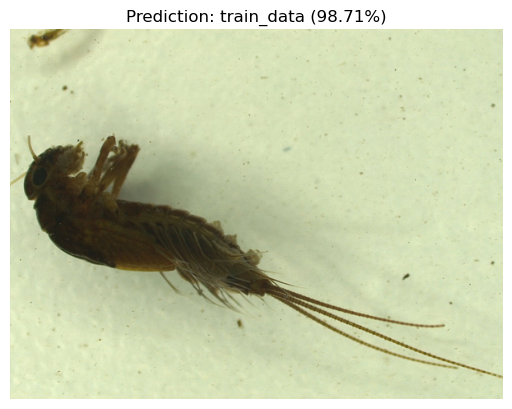

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Original Image: CPH-Leuctra sp.-1912-t.png --> Predicted: train_data (98.82%)


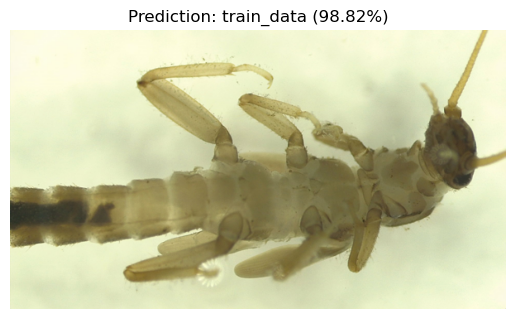

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Original Image: CPH-Limnius sp.-1929-t.png --> Predicted: train_data (98.65%)


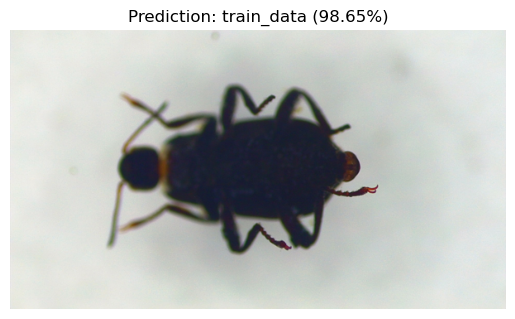

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Original Image: CPH-Limnius sp.-1925-t.png --> Predicted: train_data (98.67%)


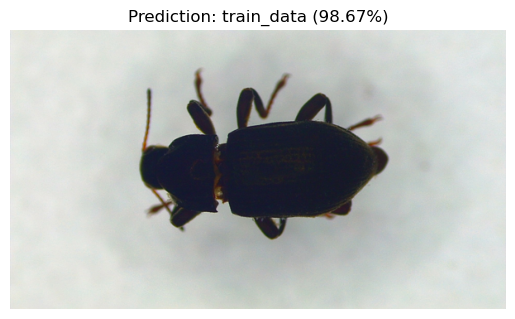

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Original Image: CPH-Limnius sp.-1924-t.png --> Predicted: train_data (98.64%)


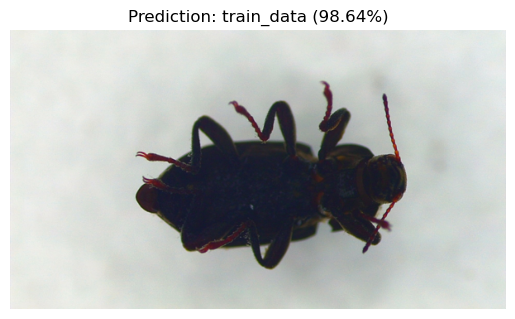

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Original Image: CPH-Leuctra sp.-1908-t.png --> Predicted: train_data (98.80%)


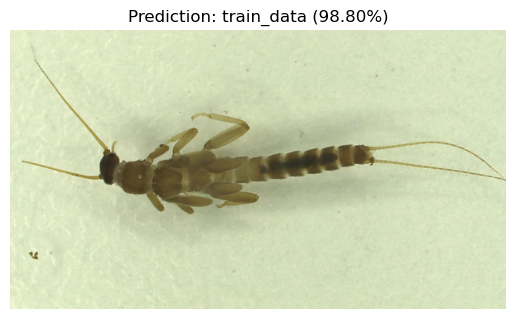

In [10]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
#TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
TEST_IMAGE_DIR = './insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)
